In [1]:
%load_ext autoreload
%autoreload 2

# Visualise sequence mutations for Thesis

Dataset overview:

1. Dataset `2024_11_27_145142` was resimulated with different starting copy numbers in the following: 
Datasets:
- Original: `2024_11_27_145142`
- Starting copies = 100, dt0 = 0.0001: `2026_01_12__18_50_13`
- Starting copies = 200, dt0 = 0.0001: `2026_01_14__22_38_47`
- Starting copies = 100, dt0 = 0.01: `2026_01_15__15_43_12`

2. Dataset `2024_11_21_160955` was resimulated as dataset `2025_02_11__13_56_51`. 

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import ast
import os

from common import set_theme, add_sample_names
from synbio_morpher.utils.results.analytics.timeseries import calculate_adaptation

PALETTE = 'viridis'

set_theme()

top_write_dir = os.path.join('figures', '04_mutations')

In [3]:
'data/raw/summarise_simulation/2024_11_21_160955/tabulated_mutation_info.csv'
'data/simulate_circuits/2026_01_12__18_50_13/config.json'
'data/simulate_circuits/2026_01_12__18_50_13/analytics.json'

'data/simulate_circuits/2026_01_12__18_50_13/analytics.json'

In [4]:
fn_og = '../data/raw/summarise_simulation/2024_11_27_145142/tabulated_mutation_info.csv'
fn_resim = '../notebooks/data/simulate_circuits/2026_01_12__18_50_13/analytics.json'
data = pd.read_csv(fn_og)
df_resim = pd.read_json(fn_resim).drop(columns='RMSE')
df_resim = df_resim.explode(df_resim.columns.to_list()).reset_index(drop=True)
cols_resim = list(df_resim.columns)

In [5]:
names_species_input = data['sample_name'].unique()
n_species_input = len(names_species_input)
n_species_total = int(len(df_resim) / len(data) * n_species_input)

df_resim = add_sample_names(df_resim, names_species_input, n_species_input, n_species_total)
data[cols_resim] = df_resim.query('sample_name in ["RNA_0", "RNA_1", "RNA_2"]')[cols_resim].values.astype(np.float32)
del df_resim

data.rename(columns={'mutation_num': 'N mutations'}, inplace=True)
data['Log sensitivity'] = np.log10(data['sensitivity'])
data['Log precision'] = np.log10(data['precision'])
data['adaptation'] = calculate_adaptation(np.array(data['sensitivity']), np.array(data['precision']), alpha=2)

In [6]:
from synbio_morpher.utils.results.analytics.naming import get_true_interaction_cols
x_cols = get_true_interaction_cols(data, 'energies', remove_symmetrical=True, num_species=3)
x_cols_self = [x_cols[0], x_cols[3], x_cols[5]]
x_cols_inter = [x_cols[1], x_cols[2], x_cols[4]]
x_cols_rna = [f'$RNA_{i}$-$RNA_{j}$' for i in range(1, 4) for j in range(1, 4) if i <= j]
titles = x_cols_rna

In [7]:
for k in ['Log sensitivity', 'Log precision', 'adaptation']:
    # data[f'{k} diffs'] = data.groupby(['circuit_name', 'sample_name'])[k].apply(lambda x: x - x.iloc[0]).reset_index()[k]
    data[f'{k} diffs'] = data.groupby(['circuit_name', 'sample_name'])[k].apply(lambda x: x - x.iloc[0]).reset_index().sort_values('level_2').reset_index()[k]
    data[f'{k} ratio'] = data.groupby(['circuit_name', 'sample_name'])[k].apply(lambda x: x/x.iloc[0]).reset_index().sort_values('level_2').reset_index()[k]

# Loss of adaptable circuits

In [8]:
filt_adapt = (data['Log sensitivity'] > -1) & (data['Log precision'] > 0.5)
filt_adapt_strict = (data['Log sensitivity'] >= 0.) & (data['Log precision'] >= 1.0)
filt_m = data['N mutations'] > 0
filt_samp = data['sample_name'] == 'RNA_2'


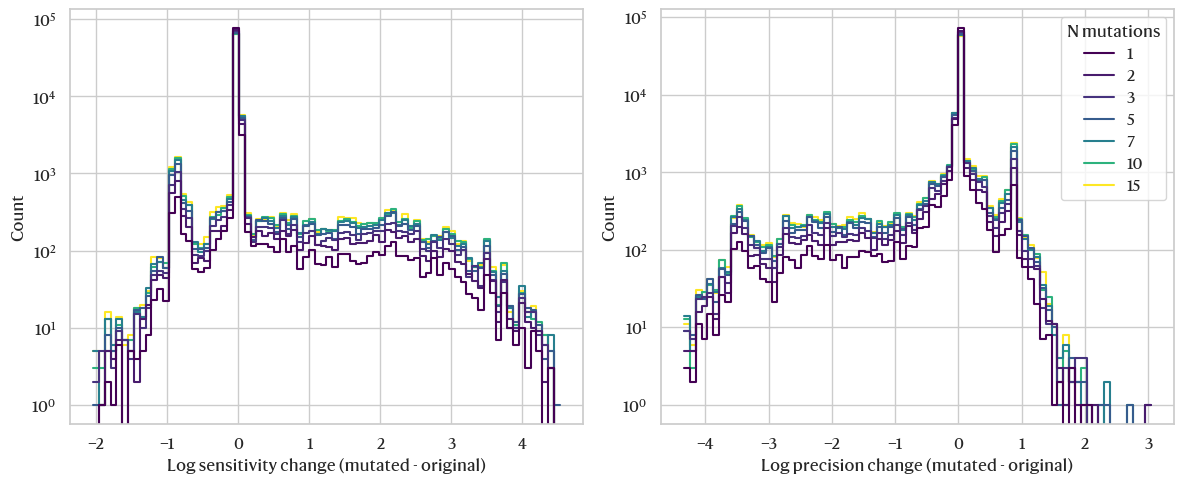

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(data[filt_adapt & filt_m & filt_samp], x=f'Log sensitivity diffs', hue='N mutations',
            palette=PALETTE, bins=80, fill=False, element='step', ax=axs[0], legend=False)
axs[0].set_yscale('log')
axs[0].set_xlabel('Log sensitivity change (mutated - original)')
sns.histplot(data[filt_adapt & filt_m & filt_samp], x=f'Log precision diffs', hue='N mutations',
            palette=PALETTE, bins=80, fill=False, element='step', ax=axs[1], legend=True)
axs[1].set_yscale('log')
axs[1].set_xlabel('Log precision change (mutated - original)')

plt.tight_layout()
plt.savefig(os.path.join(top_write_dir, 'prec_sens_diffs.png'), 
            bbox_inches='tight', dpi=300)

What are the circuits at the peaks? Is that an attractor topology?

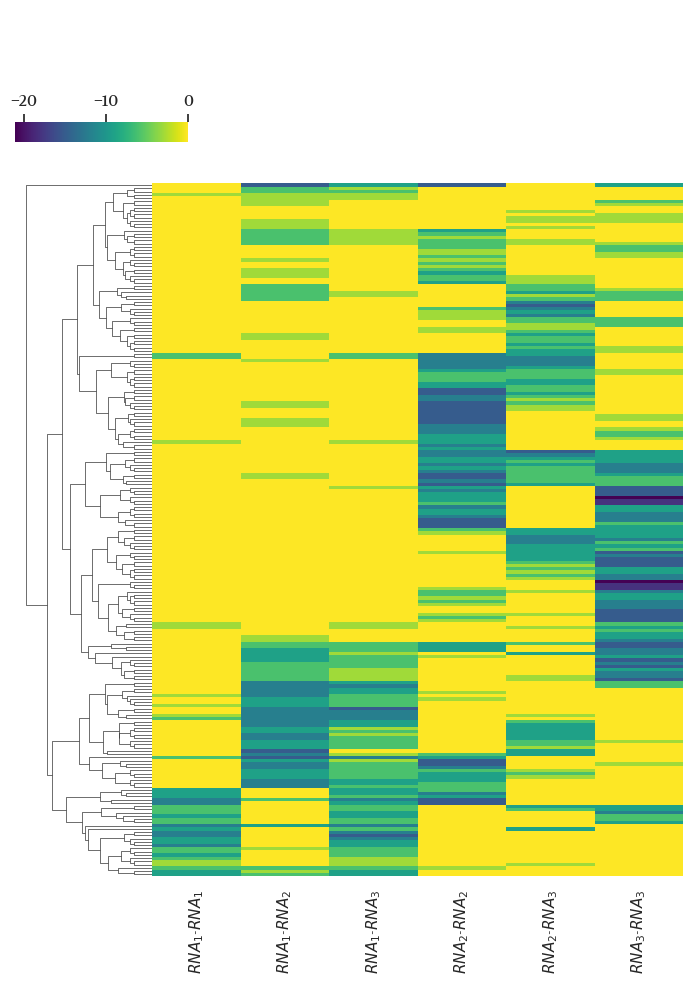

In [78]:
x_cols_quantised = [f'{i}_quant' for i in x_cols]
quantisation = 3
data[x_cols_quantised] = (data[x_cols] / quantisation).round(0) * quantisation

# cols_timeseries = ['steady_states', 'initial_steady_states']
# cols_timeseries_quantised = ['Steady states', 'Initial steady states']
# data[cols_timeseries_quantised] = (data[cols_timeseries] / 20).round(0) * 20
# from matplotlib.colors import LinearSegmentedColormap
# cmap = LinearSegmentedColormap.from_list(
#     "_",
#     [(0.0, "blue"), (0.165, "white"), (0.5, "red"), (1.0, "yellow")]
# )

cols_to_plot = x_cols_quantised # + cols_timeseries_quantised
filt_here = filt_adapt & filt_m & filt_samp & data['Log sensitivity diffs'].between(-1, -0.8)
cmap = 'viridis'
g = sns.clustermap(data[filt_here][cols_to_plot].value_counts().reset_index()[cols_to_plot].rename(
        columns={x: t for x, t in zip(x_cols_quantised, titles)}
    ), 
    cmap=cmap, col_cluster=False, figsize=(7, 10), 
    yticklabels=False, cbar_kws={'location': 'top'})
x0, _y0, _w, _h = g.cbar_pos
g.ax_cbar.set_position([x0, 0.85, g.ax_row_dendrogram.get_position().width * 1.3, 0.02])

plt.savefig(os.path.join(top_write_dir, 'mut_sensitivity_clustermap.png'),
            dpi=300, bbox_inches='tight')

In [79]:
cols_timeseries = ['steady_states', 'initial_steady_states']
data[filt_here][['Log sensitivity', 'Log precision'] + cols_timeseries].describe()

,Log sensitivity,Log precision,steady_states,initial_steady_states
count,15131.000000,15131.000000,15131.000000,15131.000000
mean,-0.603106,0.634658,94.982956,95.042267
std,0.036067,0.098169,14.735599,14.712143
min,-0.993516,0.510182,1.207712,1.208116
25%,-0.602806,0.602806,99.832886,99.866165
50%,-0.602806,0.602806,99.832886,99.866165
75%,-0.602806,0.602806,99.832886,99.866165
max,0.322396,2.318989,99.858551,99.891853


Exception ignored in: <function _xla_gc_callback at 0x7f90deeaed40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/jax/_src/lib/__init__.py", line 96, in _xla_gc_callback
    def _xla_gc_callback(*args):
KeyboardInterrupt: 
/usr/local/lib/python3.10/dist-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


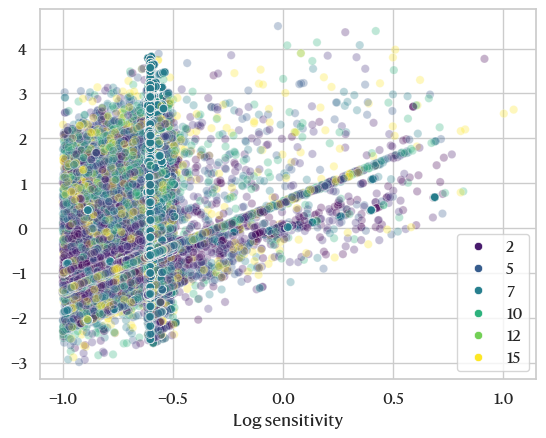

In [80]:
g = sns.scatterplot(data[filt_adapt & filt_m], x=f'Log sensitivity', 
                    y=data[filt_adapt & filt_m]['Log sensitivity diffs'].values + 
                    data[filt_adapt & filt_m]['Log sensitivity'].values, 
                hue='N mutations', palette=PALETTE, alpha=0.3)
sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1), title='Log sensitivity mutated')
for line in g.legend().get_lines():
    line.set_alpha(1.0)

# plt.tight_layout()
# plt.savefig(os.path.join(top_write_dir, 'xxx.png'), 
#             bbox_inches='tight', dpi=300)

# Visualise binding energy

In [81]:
for k in x_cols:
    data[f'{k} diffs'] = data.groupby(['circuit_name', 'sample_name'])[k].apply(lambda x: x - x.iloc[0]).reset_index().sort_values('level_2').reset_index()[k]
x_cols_diffs = [f'{k} diffs' for k in x_cols]
x_cols_self_diffs = [f'{k} diffs' for k in x_cols_self]
x_cols_inter_diffs = [f'{k} diffs' for k in x_cols_inter]


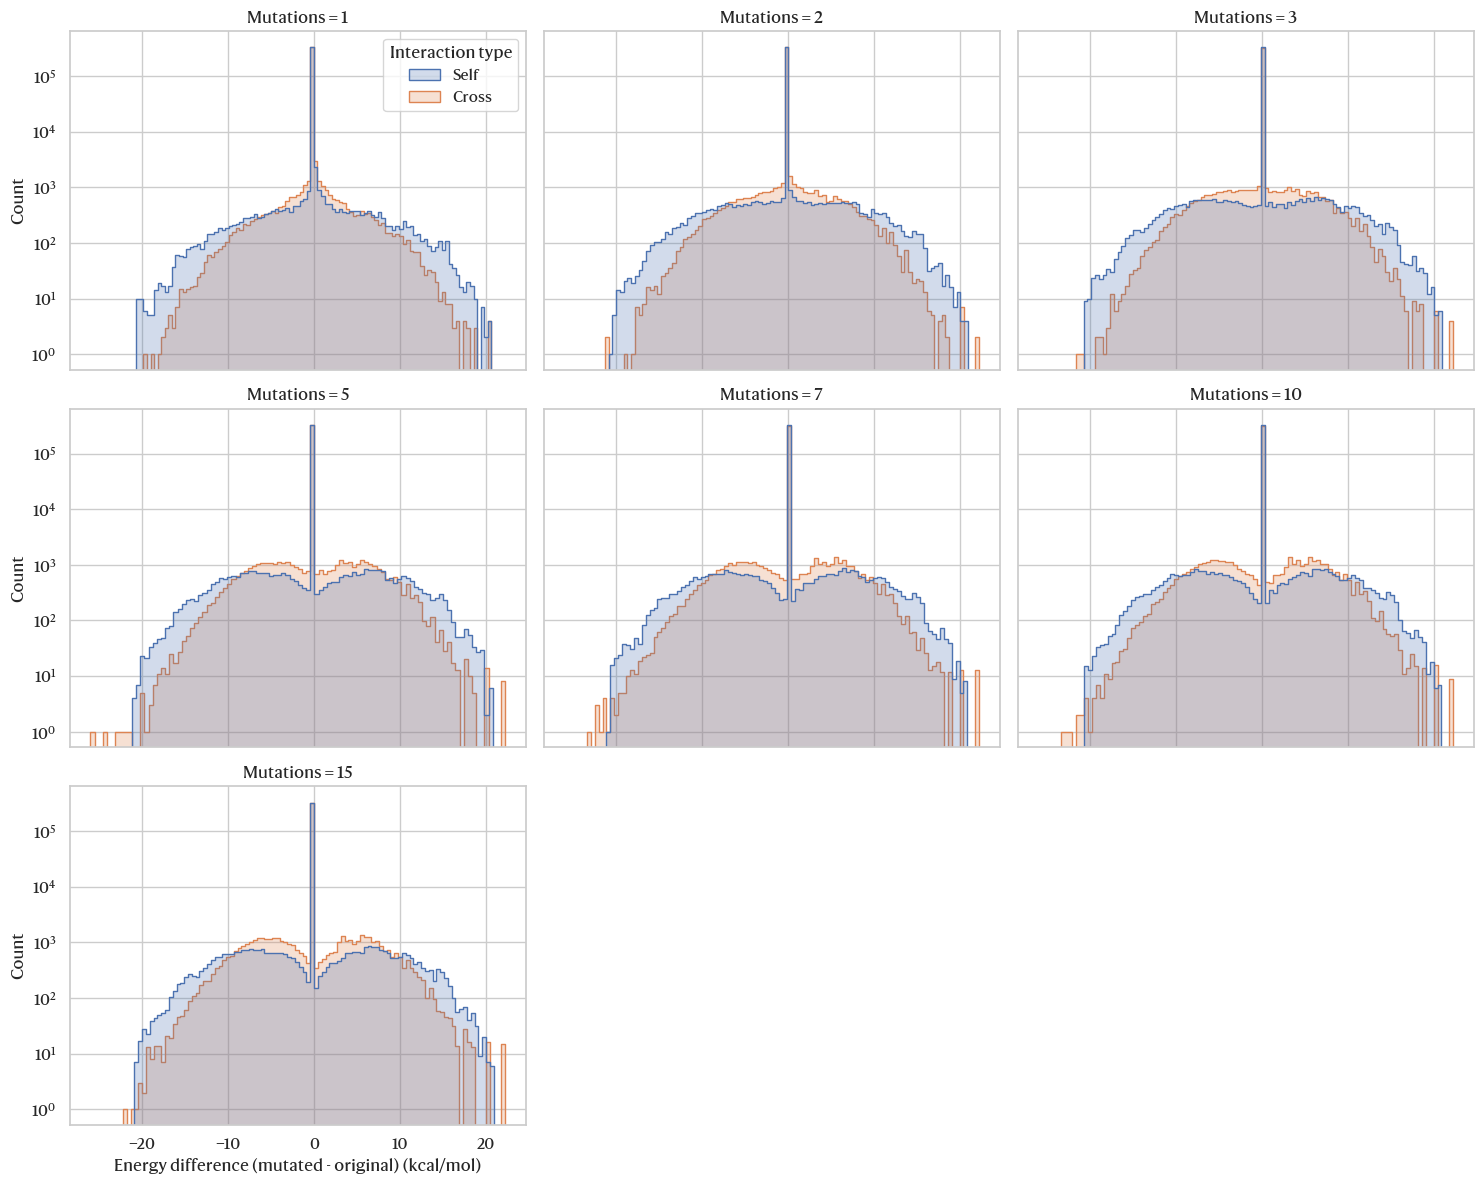

In [101]:
all_mutations = sorted(data['N mutations'].unique())[1:]
ncols = int(np.ceil(np.sqrt(len(all_mutations))))
nrows = int(np.ceil(np.sqrt(len(all_mutations))))
fig, axs = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), sharex=True, sharey=True)
for i, m in enumerate(all_mutations):
    dfm = data[filt_samp & (data['N mutations'] == m)].melt(
        value_vars=x_cols_diffs, var_name='interaction', value_name='energy_diff')
    dfm['Interaction type'] = dfm['interaction'].apply(lambda x: 'Self' if x in x_cols_self_diffs else 'Cross')
    sns.histplot(dfm, hue='Interaction type', legend=i == 0,
                x='energy_diff', bins=100, element='step', ax=axs.flat[i])
    axs.flat[i].set_yscale('log')
    axs.flat[i].set_title(f'Mutations = {m}')
    axs.flat[i].set_xlabel('Energy difference (mutated - original) (kcal/mol)')

for ii in range(i+1, ncols*nrows):
    axs.flat[ii].set_axis_off()
plt.tight_layout()
plt.savefig(os.path.join(top_write_dir, 'hist_binding_energy_selfcross.png'), bbox_inches='tight', dpi=300)

# Binding energies: functional -> null

In [ ]:
data['is_null'] = data[x_cols].sum(axis=1) == 0
circuits_null_og = data[(
    data['mutation_name'] == 'ref_circuit') & data['is_null']]['circuit_name'].unique()
data['was_only_mut_null'] = (~data['circuit_name'].isin(circuits_null_og)
                                     & data['is_null'])


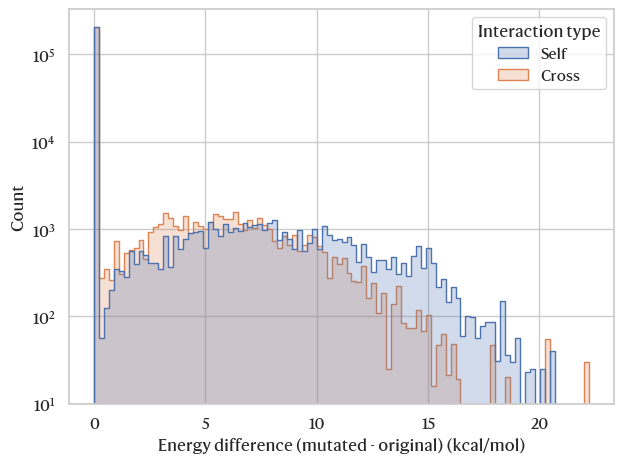

In [ ]:
dfm = data[filt_samp & data['was_only_mut_null']].melt(value_vars=x_cols_diffs, 
            var_name='interaction', value_name='energy_diff')
dfm['Interaction type'] = dfm['interaction'].apply(lambda x: 'Self' if x in x_cols_self_diffs else 'Cross')
sns.histplot(dfm, hue='Interaction type',
             x='energy_diff', bins=100, element='step', label='Self-interactions')
plt.yscale('log')
plt.xlabel('Energy difference (mutated - original) (kcal/mol)')

plt.tight_layout()
plt.savefig(os.path.join(top_write_dir, 'hist_binding_energy_selfcross_mutnull.png'), bbox_inches='tight', dpi=300)